In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [140]:
futures = pd.read_csv('Gold_INR_Futures.csv')
spot_usd = pd.read_csv('/content/XAU_USD_Spot (1).csv')
usd_inr = pd.read_csv('USD_INR.csv')

In [141]:
futures = futures[['Date', 'Futures_Price']]
spot_usd = spot_usd[['Date', 'USD_Spot_Price']]
usd_inr = usd_inr[['Date', 'USD_INR']]

In [142]:
futures['Date'] = pd.to_datetime(futures['Date'], format='%d-%m-%Y', errors='coerce')
spot_usd['Date'] = pd.to_datetime(spot_usd['Date'], format='%d-%m-%Y', errors='coerce')
usd_inr['Date'] = pd.to_datetime(usd_inr['Date'], format='%d-%m-%Y', errors='coerce')

In [143]:
futures['Date'] = futures['Date'].dt.strftime('%Y-%m-%d')
spot_usd['Date'] = spot_usd['Date'].dt.strftime('%Y-%m-%d')
usd_inr['Date'] = usd_inr['Date'].dt.strftime('%Y-%m-%d')

In [144]:
futures['Date'] = pd.to_datetime(futures['Date'])
spot_usd['Date'] = pd.to_datetime(spot_usd['Date'])
usd_inr['Date'] = pd.to_datetime(usd_inr['Date'])

In [145]:
futures['Futures_Price'] = pd.to_numeric(futures['Futures_Price'], errors='coerce')
spot_usd['USD_Spot_Price'] = pd.to_numeric(spot_usd['USD_Spot_Price'], errors='coerce')
usd_inr['USD_INR'] = pd.to_numeric(usd_inr['USD_INR'], errors='coerce')

In [146]:
futures = futures.dropna(subset=['Date', 'Futures_Price'])
spot_usd = spot_usd.dropna(subset=['Date', 'USD_Spot_Price'])
usd_inr = usd_inr.dropna(subset=['Date', 'USD_INR'])

In [147]:
print("Futures rows:", futures.shape)
print("Spot USD rows:", spot_usd.shape)
print("USD/INR rows:", usd_inr.shape)

Futures rows: (2573, 2)
Spot USD rows: (2602, 2)
USD/INR rows: (2609, 2)


In [148]:
futures = futures.sort_values('Date')
spot_usd = spot_usd.sort_values('Date')
usd_inr = usd_inr.sort_values('Date')

In [149]:
df = pd.merge(futures, spot_usd, on='Date', how='left')
df = pd.merge(df, usd_inr, on='Date', how='left')

In [150]:
df = df.ffill()

In [151]:
print(df.shape)
print(df.head())

(2573, 4)
        Date  Futures_Price  USD_Spot_Price  USD_INR
0 2015-04-01          26510         1204.10   62.142
1 2015-04-02          26548         1202.59   62.067
2 2015-04-06          26941         1214.70   62.207
3 2015-04-07          26829         1208.60   62.296
4 2015-04-08          26682         1202.80   62.192


In [152]:
df['Spot_INR_oz'] = df['USD_Spot_Price'] * df['USD_INR']
df['Spot_INR_10g'] = df['Spot_INR_oz'] * 10 / 31.1035

In [153]:
df['Basis'] = df['Futures_Price'] - df['Spot_INR_10g']

In [154]:
print(df.shape)

(2573, 7)


In [155]:
print(df[['Date', 'Futures_Price', 'Spot_INR_10g', 'Basis']].tail(20))

           Date  Futures_Price  Spot_INR_10g        Basis
2553 2025-03-04          86007  81844.676628  4162.323372
2554 2025-03-05          85848  81530.637774  4317.362226
2555 2025-03-06          86002  81405.996074  4596.003926
2556 2025-03-07          85896  81511.665568  4384.334432
2557 2025-03-10          85460  81089.178388  4370.821612
2558 2025-03-11          86113  81729.934908  4383.065092
2559 2025-03-12          86661  82154.429244  4506.570756
2560 2025-03-13          87694  83471.799556  4222.200444
2561 2025-03-14          87924  83420.984526  4503.015474
2562 2025-03-17          87976  83655.355282  4320.644718
2563 2025-03-18          88660  84385.041716  4274.958284
2564 2025-03-19          88564  84557.077435  4006.922565
2565 2025-03-20          88646  84489.999904  4156.000096
2566 2025-03-21          87785  83592.503641  4192.496359
2567 2025-03-24          87313  82861.999839  4451.000161
2568 2025-03-25          87566  83092.842461  4473.157539
2569 2025-03-2

In [156]:
import yfinance as yf

In [157]:
import yfinance as yf

rf = yf.download("^IRX", start=df['Date'].min(), end=df['Date'].max())
rf.columns = rf.columns.droplevel(1)
rf = rf[['Close']].rename(columns={'Close': 'RF'})
rf['RF'] = rf['RF'] / 100
rf = rf.reset_index()

/tmp/ipykernel_799/446942154.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  rf = yf.download("^IRX", start=df['Date'].min(), end=df['Date'].max())
[*********************100%***********************]  1 of 1 completed


In [158]:
rf.tail(20)

Price,Date,RF
2493,2025-03-03,0.04193
2494,2025-03-04,0.04195
2495,2025-03-05,0.04205
2496,2025-03-06,0.04197
2497,2025-03-07,0.04197
2498,2025-03-10,0.04185
2499,2025-03-11,0.04195
2500,2025-03-12,0.04197
2501,2025-03-13,0.04188
2502,2025-03-14,0.04188


In [159]:
rf.head()

Price,Date,RF
0,2015-04-01,0.00033
1,2015-04-02,0.00010
2,2015-04-06,0.00003
3,2015-04-07,0.00015
4,2015-04-08,0.00018


In [160]:
rf.shape

(2513, 2)

In [161]:
rf.head()

Price,Date,RF
0,2015-04-01,0.00033
1,2015-04-02,0.00010
2,2015-04-06,0.00003
3,2015-04-07,0.00015
4,2015-04-08,0.00018


In [162]:
df = pd.merge(df, rf[['Date', 'RF']], on='Date', how='inner')

In [163]:
df.tail(20)

,Date,Futures_Price,USD_Spot_Price,USD_INR,Spot_INR_oz,Spot_INR_10g,Basis,RF
2468,2025-03-03,85355,2893.71,87.260,252505.13460,81182.225344,4172.774656,0.04193
2469,2025-03-04,86007,2917.49,87.255,254565.58995,81844.676628,4162.323372,0.04195
2470,2025-03-05,85848,2918.84,86.880,253588.81920,81530.637774,4317.362226,0.04205
2471,2025-03-06,86002,2909.99,87.011,253201.13989,81405.996074,4596.003926,0.04197
2472,2025-03-07,85896,2910.79,87.100,253529.80900,81511.665568,4384.334432,0.04197
2473,2025-03-10,85460,2889.40,87.290,252215.72600,81089.178388,4370.821612,0.04185
2474,2025-03-11,86113,2916.04,87.176,254208.70304,81729.934908,4383.065092,0.04195
2475,2025-03-12,86661,2932.06,87.150,255529.02900,82154.429244,4506.570756,0.04197
2476,2025-03-13,87694,2987.75,86.897,259626.51175,83471.799556,4222.200444,0.04188
2477,2025-03-14,87924,2984.42,86.941,259468.45922,83420.984526,4503.015474,0.04188


In [179]:
c = 0.02 # Storage cost assumption
T = 30/365
df['F_theoretical'] = df['Spot_INR_10g'] * np.exp((df['RF'] + c) * T)
print(df[['Date','Futures_Price','F_theoretical','Spot_INR_10g']].tail())

           Date  Futures_Price  F_theoretical  Spot_INR_10g
2483 2025-03-24          87313   83284.101077  82861.999839
2484 2025-03-25          87566   83516.119618  83092.842461
2485 2025-03-26          87506   83542.159800  83118.204141
2486 2025-03-27          88213   84575.347591  84146.287074
2487 2025-03-28          88759   85242.651114  84810.205289


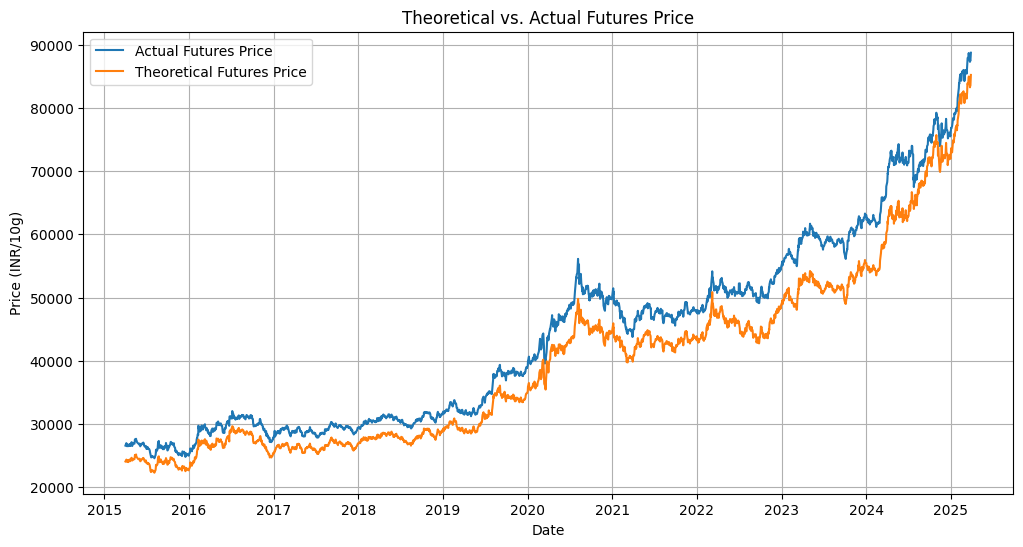

In [181]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Futures_Price'], label='Actual Futures Price')
plt.plot(df['Date'], df['F_theoretical'], label='Theoretical Futures Price')
plt.title('Theoretical vs. Actual Futures Price')
plt.xlabel('Date')
plt.ylabel('Price (INR/10g)')
plt.legend()
plt.grid(True)
plt.show()

In [165]:
df['Arbitrage'] = df['Futures_Price'] - df['F_theoretical'] # Arbitrage
df['Cash_Carry'] = df['Arbitrage'] > 0
df['Reverse_Carry'] = df['Arbitrage'] < 0
print(df[['Date','Arbitrage','Cash_Carry','Reverse_Carry']].tail())

           Date    Arbitrage  Cash_Carry  Reverse_Carry
2483 2025-03-24  4028.898923        True          False
2484 2025-03-25  4049.880382        True          False
2485 2025-03-26  3963.840200        True          False
2486 2025-03-27  3637.652409        True          False
2487 2025-03-28  3516.348886        True          False


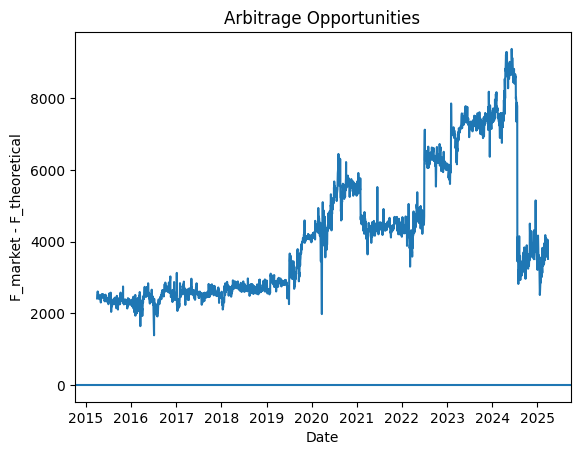

In [166]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(df['Date'], df['Arbitrage'])
plt.axhline(0)
plt.title("Arbitrage Opportunities")
plt.xlabel("Date")
plt.ylabel("F_market - F_theoretical")
plt.show()

In [167]:
df['Reverse_Carry'].describe()

,Reverse_Carry
count,2488
unique,1
top,False
freq,2488


In [168]:
df['Spot_Return'] = np.log(df['Spot_INR_10g'] / df['Spot_INR_10g'].shift(1))
df['Futures_Return'] = np.log(df['Futures_Price'] / df['Futures_Price'].shift(1))

df = df.dropna()

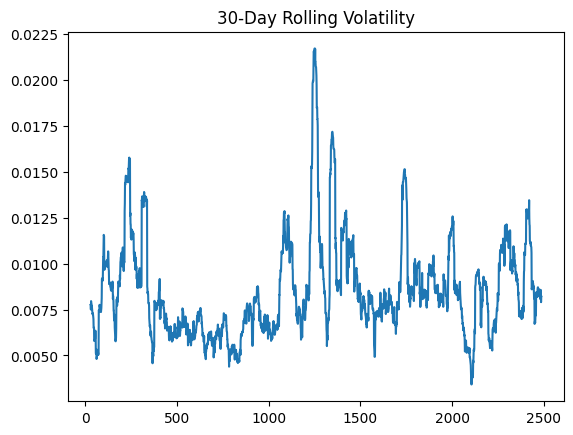

In [169]:
df['RollingVol'] = df['Spot_Return'].rolling(30).std()

plt.figure()
plt.plot(df.index, df['RollingVol'])
plt.title("30-Day Rolling Volatility")
plt.show()

In [174]:
!pip install arch
from arch import arch_model

In [171]:
model = arch_model(df['Spot_Return'], vol='Garch', p=1, q=1)
res = model.fit()

print(res.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 42478265394.97415
Iteration:      2,   Func. Count:     19,   Neg. LLF: 250715226789863.38
Iteration:      3,   Func. Count:     34,   Neg. LLF: 8627331142.948645
Iteration:      4,   Func. Count:     47,   Neg. LLF: 118.52867979615573
Iteration:      5,   Func. Count:     56,   Neg. LLF: 190275086.51816034
Iteration:      6,   Func. Count:     68,   Neg. LLF: 22782.80744021272
Iteration:      7,   Func. Count:     79,   Neg. LLF: 1.070904283947545e+17
Iteration:      8,   Func. Count:     92,   Neg. LLF: 23785599623894.562
Iteration:      9,   Func. Count:    107,   Neg. LLF: 1.4449380878635932e+18
Iteration:     10,   Func. Count:    119,   Neg. LLF: -8304.592591939763
Optimization terminated successfully    (Exit mode 0)
            Current function value: -8304.59259547522
            Iterations: 14
            Function evaluations: 119
            Gradient evaluations: 10
                     Constant Mean - GARCH Model Results

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.962e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [172]:
model2 = arch_model(
    df['Spot_Return'],
    x=df[['Futures_Return']],
    vol='Garch',
    p=1,
    q=1
)

res2 = model2.fit()

print(res2.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 42478265394.97415
Iteration:      2,   Func. Count:     19,   Neg. LLF: 250715226789863.38
Iteration:      3,   Func. Count:     34,   Neg. LLF: 8627331142.948645
Iteration:      4,   Func. Count:     47,   Neg. LLF: 118.52867979615573
Iteration:      5,   Func. Count:     56,   Neg. LLF: 190275086.51816034
Iteration:      6,   Func. Count:     68,   Neg. LLF: 22782.80744021272
Iteration:      7,   Func. Count:     79,   Neg. LLF: 1.070904283947545e+17
Iteration:      8,   Func. Count:     92,   Neg. LLF: 23785599623894.562
Iteration:      9,   Func. Count:    107,   Neg. LLF: 1.4449380878635932e+18
Iteration:     10,   Func. Count:    119,   Neg. LLF: -8304.592591939763
Optimization terminated successfully    (Exit mode 0)
            Current function value: -8304.59259547522
            Iterations: 14
            Function evaluations: 119
            Gradient evaluations: 10
                     Constant Mean - GARCH Model Results

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.962e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [173]:
split_date = "2022-01-01"

before = df.loc[:split_date, 'RollingVol']
after = df.loc[split_date:, 'RollingVol']

print("Before:", before.mean())
print("After:", after.mean())

Before: 0.00856116576684048
After: 0.008427982751476566


In [182]:
df.to_csv('analyzed_data.csv', index=False)
print('DataFrame saved to analyzed_data.csv')

DataFrame saved to analyzed_data.csv


In [183]:
df.head()

,Date,Futures_Price,USD_Spot_Price,USD_INR,Spot_INR_oz,Spot_INR_10g,Basis,RF,F_theoretical,Arbitrage,Cash_Carry,Reverse_Carry,Spot_Return,Futures_Return,RollingVol
1,2015-04-02,26548,1202.59,62.067,74641.15353,23997.670208,2550.329792,0.00010,24037.348440,2510.651560,True,False,-0.002462,0.001432,NaN
2,2015-04-06,26941,1214.70,62.207,75562.84290,24294.000000,2647.000000,0.00003,24334.028186,2606.971814,True,False,0.012273,0.014695,NaN
3,2015-04-07,26829,1208.60,62.296,75290.94560,24206.583053,2622.416947,0.00015,24246.706350,2582.293650,True,False,-0.003605,-0.004166,NaN
4,2015-04-08,26682,1202.80,62.192,74804.53760,24050.199367,2631.800633,0.00018,24090.122852,2591.877148,True,False,-0.006481,-0.005494,NaN
5,2015-04-09,26452,1195.01,62.306,74456.29306,23938.236231,2513.763769,0.00020,23978.013272,2473.986728,True,False,-0.004666,-0.008657,NaN
